target: Sprawdzić, czy w danych widać potencjał redukcji mocy/energii elektrofiltru bez pogorszenia emisji bazowej pyłu.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

DF_MODEL_PATH = DATA_PROCESSED / "df_model_clean_v1.parquet"
TAG_CLASSIFICATION_PATH = DATA_PROCESSED / "tag_classification_v1.xlsx"
RAPPING_FEATURES_PATH = DATA_PROCESSED / "rapping_features_v1.parquet"

print(PROJECT_ROOT)
print(DATA_PROCESSED)

c:\Users\karol\Desktop\esp_industrial_ml
c:\Users\karol\Desktop\esp_industrial_ml\data\processed


In [2]:
df = pd.read_parquet(DF_MODEL_PATH)
classified = pd.read_excel(TAG_CLASSIFICATION_PATH)
rapping_features = pd.read_parquet(RAPPING_FEATURES_PATH)

print("df:", df.shape)
print("classified:", classified.shape)
print("rapping_features:", rapping_features.shape)

print("df time range:", df.index.min(), "->", df.index.max())
print("rapping features time range:", rapping_features.index.min(), "->", rapping_features.index.max())

df.head()

df: (210644, 76)
classified: (76, 7)
rapping_features: (210644, 3)
df time range: 2025-06-30 00:00:00 -> 2025-08-01 00:00:00
rapping features time range: 2025-06-30 00:00:00 -> 2025-08-01 00:00:00


,008A01345,008A00444,008A00936,008A00910,008A00911,008A00720,008A00728,008A02273,008A02274,008A02275,008A00719,008A00727,008A01350,008A01341,008A01343,008A01347,008A02118,016A00219,008A00723,016A00396,008A00731,008A01353,008B01474,008B01479,008B01484,008B01489,008A00741,008A00742,008B05167,008A02270,008A02292,008B05155,008A02267,008A02289,008A02264,008B05146,008B05131,008B05140,008A02276,008A02277,008B05100,008B05103,008A02282,008A02283,008B05173,008A02271,008A02293,008A02268,008A02290,008A02265,008B05150,008B05135,008A02278,008B05106,008A02284,008A02279,008B05109,008A02285,008B05178,008A02272,008A02294,008A02269,008A02291,008A02266,008B05154,008B05139,008A02280,008B05112,008A02286,008A02281,008B05115,008A02287,008B05096,008B05121,008B05126,008B05117
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-06-30 00:00:00,11.0,186.0,32.500000,68282.0,73877.0,124.0,126.0,14.0,12.1,11.2,-0.63,-0.55,8.4,1315.0,174.0,46.0,4.9,137.0,13.0,149.0,14.0,146.0,0.0,0.0,0.0,0.0,5.1,8.9,1.0,266.0,390.0,1.0,296.0,47.0,0.0,0.0,0.0,1.0,103.0,83.0,0.0,0.0,91.0,86.0,1.0,212.0,392.0,306.0,39.0,0.0,0.0,0.0,88.0,0.0,47.0,70.0,1.0,44.0,1.0,212.0,388.0,304.0,37.0,0.0,0.0,0.0,49.0,1.0,37.0,88.0,0.0,32.0,1.0,1.0,1.0,1.0
2025-06-30 00:00:10,11.0,186.0,31.700001,68103.0,73804.0,124.0,126.0,14.0,12.1,11.2,-0.63,-0.55,8.4,1315.0,174.0,46.0,4.9,137.0,13.0,149.0,13.0,146.0,0.0,0.0,0.0,0.0,5.1,9.0,1.0,266.0,391.0,1.0,296.0,47.0,0.0,0.0,0.0,1.0,103.0,83.0,0.0,0.0,91.0,86.0,1.0,211.0,393.0,306.0,39.0,0.0,0.0,0.0,88.0,0.0,47.0,70.0,1.0,44.0,1.0,214.0,388.0,301.0,37.0,0.0,0.0,0.0,49.0,1.0,37.0,88.0,0.0,32.0,1.0,1.0,1.0,1.0
2025-06-30 00:00:20,11.0,186.0,32.000000,68766.0,73499.0,124.0,126.0,14.0,12.1,11.3,-0.63,-0.55,8.2,1308.0,174.0,44.0,4.9,136.0,13.0,149.0,13.0,151.0,0.0,0.0,0.0,0.0,5.1,9.1,1.0,267.0,391.0,1.0,296.0,47.0,0.0,0.0,0.0,1.0,103.0,83.0,0.0,0.0,92.0,86.0,1.0,214.0,391.0,306.0,39.0,0.0,0.0,0.0,88.0,0.0,47.0,70.0,1.0,44.0,1.0,217.0,385.0,304.0,37.0,0.0,0.0,0.0,49.0,1.0,37.0,88.0,0.0,32.0,1.0,1.0,1.0,1.0
2025-06-30 00:00:30,11.0,186.0,31.799999,68103.0,73645.0,124.0,126.0,13.8,11.8,11.2,-0.63,-0.55,8.2,1308.0,174.0,44.0,4.9,136.0,13.0,149.0,14.0,151.0,0.0,0.0,0.0,0.0,5.2,9.0,1.0,266.0,389.0,1.0,294.0,47.0,0.0,0.0,0.0,1.0,103.0,83.0,0.0,0.0,92.0,87.0,1.0,209.0,393.0,301.0,39.0,0.0,0.0,0.0,88.0,1.0,47.0,70.0,1.0,44.0,1.0,214.0,386.0,304.0,37.0,0.0,0.0,0.0,49.0,1.0,37.0,88.0,0.0,32.0,1.0,1.0,1.0,1.0
2025-06-30 00:00:40,9.0,186.0,32.400002,68209.0,73645.0,125.0,126.0,14.0,11.9,11.2,-0.63,-0.54,8.2,1313.0,173.0,45.0,4.9,136.0,13.0,149.0,14.0,150.0,0.0,0.0,0.0,0.0,5.2,9.1,1.0,269.0,389.0,1.0,296.0,47.0,0.0,0.0,0.0,1.0,103.0,83.0,0.0,0.0,92.0,87.0,1.0,207.0,394.0,301.0,39.0,0.0,0.0,0.0,88.0,1.0,47.0,70.0,1.0,44.0,1.0,209.0,386.0,304.0,37.0,0.0,0.0,0.0,49.0,1.0,37.0,87.0,0.0,32.0,1.0,1.0,1.0,1.0


In [3]:
target_col = "008A01345"  # Pył BC1 Stężenie aktualne

esp_power_cols = [
    "008A02273",  # Zespół Zasil WN str 1A Moc Zespołu
    "008A02274",  # Zespół Zasil WN str 2A Moc Zespołu
    "008A02275",  # Zespół Zasil WN str 3A Moc Zespołu
]

classified[classified["tag"].isin(esp_power_cols + [target_col])][
    ["tag", "description", "symbol", "unit", "category"]
]

,tag,description,symbol,unit,category
6,008A02273,Zespół Zasil WN str 1A Moc Zespołu,08_NZ_WN_1A,kW,esp_power
7,008A02274,Zespół Zasil WN str 2A Moc Zespołu,08_NZ_WN_2A,kW,esp_power
8,008A02275,Zespół Zasil WN str 3A Moc Zespołu,08_NZ_WN_3A,kW,esp_power
15,008A01345,Pył BC1 Steżenie aktualne,08_Q_PYL_KOM,mg/Nm3,target


In [4]:
df_energy = df.copy()

df_energy["esp_power_total"] = df_energy[esp_power_cols].sum(axis=1)

df_energy[
    esp_power_cols + ["esp_power_total", target_col]
].describe()

,008A02273,008A02274,008A02275,esp_power_total,008A01345
count,210644.000000,210644.000000,210644.000000,210644.000000,210644.000000
mean,14.549759,12.960008,12.380282,39.890049,11.149162
std,2.902526,3.371408,3.711896,9.572117,4.822527
min,7.100000,3.200000,10.800000,31.200000,2.000000
25%,13.900000,12.300000,11.600000,37.900001,9.000000
50%,14.000000,12.500000,11.700000,38.299999,11.000000
75%,14.500000,12.600000,11.800000,38.700001,13.000000
max,100.000000,103.699997,97.199997,288.699997,101.000000


In [5]:
critical_time_col = "minutes_since_rapping_3_collecting_start_0_5"

df_energy = df_energy.join(
    rapping_features[[critical_time_col]],
    how="left"
)

# poza oknem 0–5 min w rapping_features było -1
mask_after_rapping_0_3min = (
    (df_energy[critical_time_col] >= 0) &
    (df_energy[critical_time_col] <= 3)
)

df_energy_base = df_energy.loc[~mask_after_rapping_0_3min].copy()

print("Before:", df_energy.shape)
print("After removing 0–3 min after 008B05154:", df_energy_base.shape)
print("Removed samples:", mask_after_rapping_0_3min.sum())
print("Removed percent:", round(mask_after_rapping_0_3min.mean() * 100, 3), "%")

Before: (210644, 78)
After removing 0–3 min after 008B05154: (202607, 78)
Removed samples: 8037
Removed percent: 3.815 %


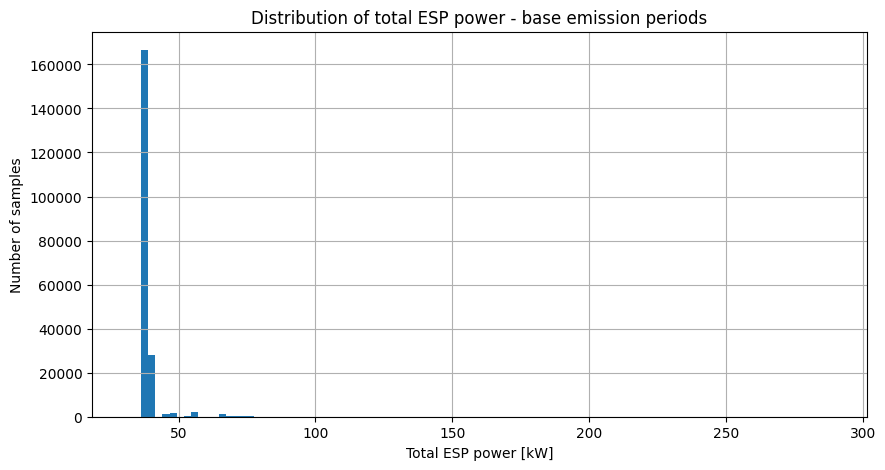

In [6]:
plt.figure(figsize=(10, 5))

plt.hist(df_energy_base["esp_power_total"], bins=100)

plt.title("Distribution of total ESP power - base emission periods")
plt.xlabel("Total ESP power [kW]")
plt.ylabel("Number of samples")
plt.grid(True)
plt.show()

In [7]:
power_thresholds = [40, 50, 75, 100, 150, 200]

for threshold in power_thresholds:
    n = (df_energy_base["esp_power_total"] > threshold).sum()
    p = (df_energy_base["esp_power_total"] > threshold).mean() * 100
    print(f"Power > {threshold} kW: {n} samples ({p:.3f}%)")

Power > 40 kW: 8818 samples (4.352%)
Power > 50 kW: 5059 samples (2.497%)
Power > 75 kW: 1083 samples (0.535%)
Power > 100 kW: 509 samples (0.251%)
Power > 150 kW: 320 samples (0.158%)
Power > 200 kW: 226 samples (0.112%)


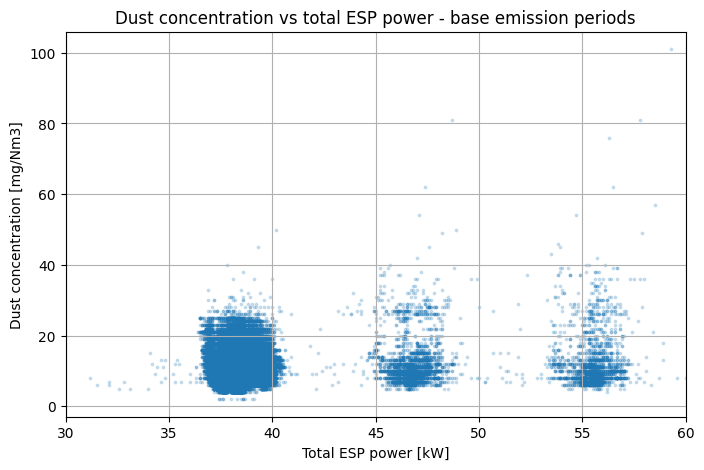

In [8]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_energy_base["esp_power_total"],
    df_energy_base[target_col],
    s=3,
    alpha=0.2
)

plt.xlim(30, 60)

plt.title("Dust concentration vs total ESP power - base emission periods")
plt.xlabel("Total ESP power [kW]")
plt.ylabel("Dust concentration [mg/Nm3]")
plt.grid(True)
plt.show()

In [9]:
power_bins = [30, 42, 52, 65, np.inf]
power_labels = ["low_power_30_42", "mid_power_42_52", "high_power_52_65", "extreme_power_gt_65"]

df_energy_base["power_regime"] = pd.cut(
    df_energy_base["esp_power_total"],
    bins=power_bins,
    labels=power_labels,
    include_lowest=True
)

power_regime_summary = (
    df_energy_base
    .groupby("power_regime", observed=True)
    .agg(
        n_samples=(target_col, "count"),
        mean_power=("esp_power_total", "mean"),
        median_power=("esp_power_total", "median"),
        mean_dust=(target_col, "mean"),
        median_dust=(target_col, "median"),
        q90_dust=(target_col, lambda x: x.quantile(0.90)),
        q95_dust=(target_col, lambda x: x.quantile(0.95)),
        max_dust=(target_col, "max"),
    )
    .reset_index()
)

power_regime_summary

,power_regime,n_samples,mean_power,median_power,mean_dust,median_dust,q90_dust,q95_dust,max_dust
0,low_power_30_42,194552,38.281590,38.200000,10.702357,11.0,15.0,17.0,50.0
1,mid_power_42_52,3014,46.764034,46.700001,11.974453,10.0,21.0,27.0,81.0
2,high_power_52_65,2456,55.991002,55.599999,12.254072,10.0,23.0,28.0,101.0
3,extreme_power_gt_65,2585,93.862708,71.800001,13.210058,10.0,26.0,31.0,101.0


In [10]:
boiler_load_cols = [
    "016A00219",  # R1 P13 Moc czynna całkowita
    "016A00396",  # R1 P18 Moc czynna całkowita
]

df_energy_base["boiler_load_total"] = df_energy_base[boiler_load_cols].sum(axis=1)

power_regime_process_summary = (
    df_energy_base
    .groupby("power_regime", observed=True)
    .agg(
        n_samples=(target_col, "count"),
        mean_esp_power=("esp_power_total", "mean"),
        mean_dust=(target_col, "mean"),
        median_dust=(target_col, "median"),
        mean_boiler_load=("boiler_load_total", "mean"),
        median_boiler_load=("boiler_load_total", "median"),
    )
    .reset_index()
)

power_regime_process_summary

,power_regime,n_samples,mean_esp_power,mean_dust,median_dust,mean_boiler_load,median_boiler_load
0,low_power_30_42,194552,38.281590,10.702357,11.0,290.422792,288.0
1,mid_power_42_52,3014,46.764034,11.974453,10.0,297.648971,292.0
2,high_power_52_65,2456,55.991002,12.254072,10.0,300.886401,294.5
3,extreme_power_gt_65,2585,93.862708,13.210058,10.0,304.148162,296.0


In [11]:
df_energy_base["boiler_load_bin"] = pd.qcut(
    df_energy_base["boiler_load_total"],
    q=4,
    duplicates="drop"
)

boiler_power_summary = (
    df_energy_base
    .groupby(["boiler_load_bin", "power_regime"], observed=True)
    .agg(
        n_samples=(target_col, "count"),
        mean_boiler_load=("boiler_load_total", "mean"),
        mean_esp_power=("esp_power_total", "mean"),
        median_esp_power=("esp_power_total", "median"),
        mean_dust=(target_col, "mean"),
        median_dust=(target_col, "median"),
        q90_dust=(target_col, lambda x: x.quantile(0.90)),
        q95_dust=(target_col, lambda x: x.quantile(0.95)),
    )
    .reset_index()
)

boiler_power_summary

,boiler_load_bin,power_regime,n_samples,mean_boiler_load,mean_esp_power,median_esp_power,mean_dust,median_dust,q90_dust,q95_dust
0,"(252.999, 284.0]",low_power_30_42,58939,281.252600,38.096140,38.100000,9.463140,9.0,13.0,15.00
1,"(252.999, 284.0]",mid_power_42_52,511,281.522505,46.716634,46.799999,8.659491,8.0,11.0,12.50
2,"(252.999, 284.0]",high_power_52_65,332,281.852410,55.503012,55.599998,8.045181,8.0,9.0,11.00
3,"(252.999, 284.0]",extreme_power_gt_65,380,281.776316,140.058158,95.750002,6.089474,6.0,9.0,9.00
4,"(284.0, 288.0]",low_power_30_42,42636,286.483113,38.177974,38.200000,9.939535,9.0,13.0,15.00
5,"(284.0, 288.0]",mid_power_42_52,550,286.621818,46.627091,46.700001,9.001818,9.0,12.0,13.00
6,"(284.0, 288.0]",high_power_52_65,338,286.520710,55.522189,55.499999,8.739645,8.0,11.0,12.15
7,"(284.0, 288.0]",extreme_power_gt_65,235,286.817021,85.580426,67.000000,7.178723,7.0,10.6,12.30
8,"(288.0, 294.0]",low_power_30_42,49137,291.265523,38.389497,38.300000,10.822211,11.0,14.0,17.00
9,"(288.0, 294.0]",mid_power_42_52,679,291.368189,46.897938,46.800000,10.329897,9.0,14.0,21.10


In [12]:
boiler_power_summary_filtered = boiler_power_summary[
    boiler_power_summary["n_samples"] >= 200
].copy()

boiler_power_summary_filtered

,boiler_load_bin,power_regime,n_samples,mean_boiler_load,mean_esp_power,median_esp_power,mean_dust,median_dust,q90_dust,q95_dust
0,"(252.999, 284.0]",low_power_30_42,58939,281.252600,38.096140,38.100000,9.463140,9.0,13.0,15.00
1,"(252.999, 284.0]",mid_power_42_52,511,281.522505,46.716634,46.799999,8.659491,8.0,11.0,12.50
2,"(252.999, 284.0]",high_power_52_65,332,281.852410,55.503012,55.599998,8.045181,8.0,9.0,11.00
3,"(252.999, 284.0]",extreme_power_gt_65,380,281.776316,140.058158,95.750002,6.089474,6.0,9.0,9.00
4,"(284.0, 288.0]",low_power_30_42,42636,286.483113,38.177974,38.200000,9.939535,9.0,13.0,15.00
5,"(284.0, 288.0]",mid_power_42_52,550,286.621818,46.627091,46.700001,9.001818,9.0,12.0,13.00
6,"(284.0, 288.0]",high_power_52_65,338,286.520710,55.522189,55.499999,8.739645,8.0,11.0,12.15
7,"(284.0, 288.0]",extreme_power_gt_65,235,286.817021,85.580426,67.000000,7.178723,7.0,10.6,12.30
8,"(288.0, 294.0]",low_power_30_42,49137,291.265523,38.389497,38.300000,10.822211,11.0,14.0,17.00
9,"(288.0, 294.0]",mid_power_42_52,679,291.368189,46.897938,46.800000,10.329897,9.0,14.0,21.10


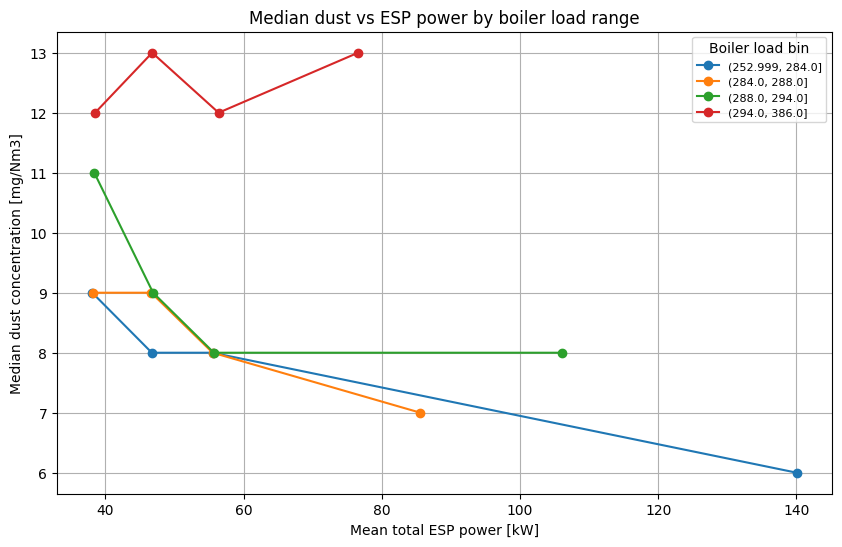

In [13]:
plt.figure(figsize=(10, 6))

for load_bin, group in boiler_power_summary_filtered.groupby("boiler_load_bin", observed=True):
    group = group.sort_values("mean_esp_power")

    plt.plot(
        group["mean_esp_power"],
        group["median_dust"],
        marker="o",
        label=str(load_bin)
    )

plt.title("Median dust vs ESP power by boiler load range")
plt.xlabel("Mean total ESP power [kW]")
plt.ylabel("Median dust concentration [mg/Nm3]")
plt.legend(title="Boiler load bin", fontsize=8)
plt.grid(True)
plt.show()

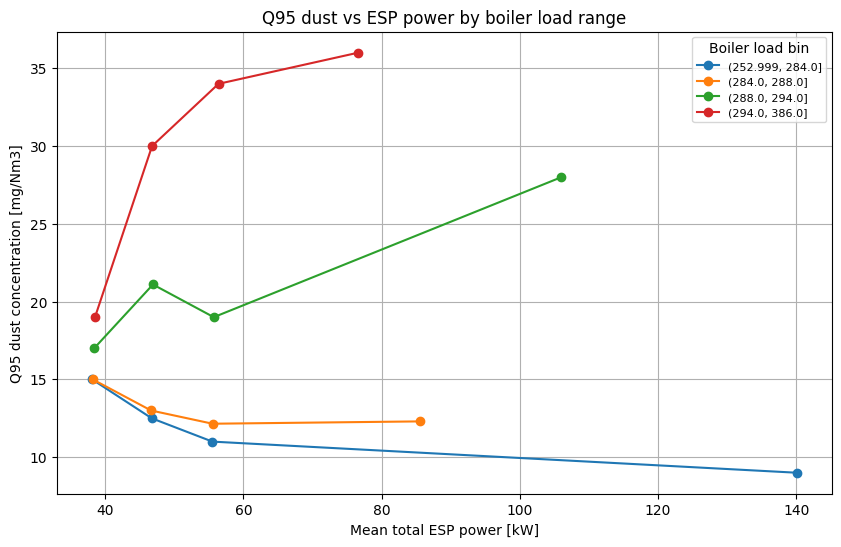

In [14]:
plt.figure(figsize=(10, 6))

for load_bin, group in boiler_power_summary_filtered.groupby("boiler_load_bin", observed=True):
    group = group.sort_values("mean_esp_power")

    plt.plot(
        group["mean_esp_power"],
        group["q95_dust"],
        marker="o",
        label=str(load_bin)
    )

plt.title("Q95 dust vs ESP power by boiler load range")
plt.xlabel("Mean total ESP power [kW]")
plt.ylabel("Q95 dust concentration [mg/Nm3]")
plt.legend(title="Boiler load bin", fontsize=8)
plt.grid(True)
plt.show()

In [15]:
boiler_power_summary_filtered.sort_values(
    ["boiler_load_bin", "mean_esp_power"]
)

,boiler_load_bin,power_regime,n_samples,mean_boiler_load,mean_esp_power,median_esp_power,mean_dust,median_dust,q90_dust,q95_dust
0,"(252.999, 284.0]",low_power_30_42,58939,281.252600,38.096140,38.100000,9.463140,9.0,13.0,15.00
1,"(252.999, 284.0]",mid_power_42_52,511,281.522505,46.716634,46.799999,8.659491,8.0,11.0,12.50
2,"(252.999, 284.0]",high_power_52_65,332,281.852410,55.503012,55.599998,8.045181,8.0,9.0,11.00
3,"(252.999, 284.0]",extreme_power_gt_65,380,281.776316,140.058158,95.750002,6.089474,6.0,9.0,9.00
4,"(284.0, 288.0]",low_power_30_42,42636,286.483113,38.177974,38.200000,9.939535,9.0,13.0,15.00
5,"(284.0, 288.0]",mid_power_42_52,550,286.621818,46.627091,46.700001,9.001818,9.0,12.0,13.00
6,"(284.0, 288.0]",high_power_52_65,338,286.520710,55.522189,55.499999,8.739645,8.0,11.0,12.15
7,"(284.0, 288.0]",extreme_power_gt_65,235,286.817021,85.580426,67.000000,7.178723,7.0,10.6,12.30
8,"(288.0, 294.0]",low_power_30_42,49137,291.265523,38.389497,38.300000,10.822211,11.0,14.0,17.00
9,"(288.0, 294.0]",mid_power_42_52,679,291.368189,46.897938,46.800000,10.329897,9.0,14.0,21.10


In [16]:
boiler_power_summary_filtered = boiler_power_summary_filtered.copy()

boiler_power_summary_filtered["q95_per_kw"] = (
    boiler_power_summary_filtered["q95_dust"] /
    boiler_power_summary_filtered["mean_esp_power"]
)

boiler_power_summary_filtered["mean_dust_per_kw"] = (
    boiler_power_summary_filtered["mean_dust"] /
    boiler_power_summary_filtered["mean_esp_power"]
)

boiler_power_summary_filtered.sort_values(
    ["boiler_load_bin", "mean_esp_power"]
)

,boiler_load_bin,power_regime,n_samples,mean_boiler_load,mean_esp_power,median_esp_power,mean_dust,median_dust,q90_dust,q95_dust,q95_per_kw,mean_dust_per_kw
0,"(252.999, 284.0]",low_power_30_42,58939,281.252600,38.096140,38.100000,9.463140,9.0,13.0,15.00,0.393741,0.248402
1,"(252.999, 284.0]",mid_power_42_52,511,281.522505,46.716634,46.799999,8.659491,8.0,11.0,12.50,0.267571,0.185362
2,"(252.999, 284.0]",high_power_52_65,332,281.852410,55.503012,55.599998,8.045181,8.0,9.0,11.00,0.198187,0.144950
3,"(252.999, 284.0]",extreme_power_gt_65,380,281.776316,140.058158,95.750002,6.089474,6.0,9.0,9.00,0.064259,0.043478
4,"(284.0, 288.0]",low_power_30_42,42636,286.483113,38.177974,38.200000,9.939535,9.0,13.0,15.00,0.392897,0.260347
5,"(284.0, 288.0]",mid_power_42_52,550,286.621818,46.627091,46.700001,9.001818,9.0,12.0,13.00,0.278808,0.193060
6,"(284.0, 288.0]",high_power_52_65,338,286.520710,55.522189,55.499999,8.739645,8.0,11.0,12.15,0.218831,0.157408
7,"(284.0, 288.0]",extreme_power_gt_65,235,286.817021,85.580426,67.000000,7.178723,7.0,10.6,12.30,0.143724,0.083883
8,"(288.0, 294.0]",low_power_30_42,49137,291.265523,38.389497,38.300000,10.822211,11.0,14.0,17.00,0.442829,0.281906
9,"(288.0, 294.0]",mid_power_42_52,679,291.368189,46.897938,46.800000,10.329897,9.0,14.0,21.10,0.449913,0.220263


In [17]:
tradeoff_rows = []

for load_bin, group in boiler_power_summary_filtered.groupby("boiler_load_bin", observed=True):
    group = group.sort_values("mean_esp_power").reset_index(drop=True)

    if len(group) < 2:
        continue

    ref = group.iloc[0]

    for i in range(1, len(group)):
        row = group.iloc[i]

        tradeoff_rows.append({
            "boiler_load_bin": load_bin,
            "reference_power": ref["mean_esp_power"],
            "compared_power": row["mean_esp_power"],
            "delta_power_kw": row["mean_esp_power"] - ref["mean_esp_power"],
            "reference_q95_dust": ref["q95_dust"],
            "compared_q95_dust": row["q95_dust"],
            "delta_q95_dust": row["q95_dust"] - ref["q95_dust"],
            "reference_median_dust": ref["median_dust"],
            "compared_median_dust": row["median_dust"],
            "delta_median_dust": row["median_dust"] - ref["median_dust"],
            "reference_n": ref["n_samples"],
            "compared_n": row["n_samples"],
        })

tradeoff_summary = pd.DataFrame(tradeoff_rows)

tradeoff_summary

,boiler_load_bin,reference_power,compared_power,delta_power_kw,reference_q95_dust,compared_q95_dust,delta_q95_dust,reference_median_dust,compared_median_dust,delta_median_dust,reference_n,compared_n
0,"(252.999, 284.0]",38.096140,46.716634,8.620494,15.0,12.50,-2.50,9.0,8.0,-1.0,58939,511
1,"(252.999, 284.0]",38.096140,55.503012,17.406872,15.0,11.00,-4.00,9.0,8.0,-1.0,58939,332
2,"(252.999, 284.0]",38.096140,140.058158,101.962018,15.0,9.00,-6.00,9.0,6.0,-3.0,58939,380
3,"(284.0, 288.0]",38.177974,46.627091,8.449117,15.0,13.00,-2.00,9.0,9.0,0.0,42636,550
4,"(284.0, 288.0]",38.177974,55.522189,17.344215,15.0,12.15,-2.85,9.0,8.0,-1.0,42636,338
5,"(284.0, 288.0]",38.177974,85.580426,47.402452,15.0,12.30,-2.70,9.0,7.0,-2.0,42636,235
6,"(288.0, 294.0]",38.389497,46.897938,8.508441,17.0,21.10,4.10,11.0,9.0,-2.0,49137,679
7,"(288.0, 294.0]",38.389497,55.699462,17.309966,17.0,19.00,2.00,11.0,8.0,-3.0,49137,558
8,"(288.0, 294.0]",38.389497,106.012440,67.622943,17.0,28.00,11.00,11.0,8.0,-3.0,49137,627
9,"(294.0, 386.0]",38.510737,46.770801,8.260064,19.0,30.00,11.00,12.0,13.0,1.0,43840,1274


In [18]:
process_context_cols = [
    "016A00219",  # boiler load P13
    "016A00396",  # boiler load P18
    "008A00720",  # T spalin za podgrz. pow. OPP str.L
    "008A00728",  # T spalin za podgrz. pow. OPP str.P
    "008A01350",  # O2 lewa
    "008A00741",  # O2 przed OPP L
    "008A00742",  # O2 przed OPP P
]

classified[classified["tag"].isin(process_context_cols)][
    ["tag", "description", "symbol", "unit", "category"]
]

,tag,description,symbol,unit,category
4,008A00720,T spalin za podgrz. pow. OPP str.L,08_P_SPAPRZEZDELF_L,stC,flue_gas_temperature
5,008A00728,T spalin za podgrz. pow. OPP str.P,08_T_SPAPRZEDELF_P,stC,flue_gas_temperature
11,008A01350,O2 strona lewa BC1 Steżenie aktualne,08_O2_SP_L,%,flue_gas_o2
17,016A00219,R1 P13 Moc czynna całkowita,16_R1P13PECA_PCZ,kW,boiler_load
19,016A00396,R1 P18 Moc czynna całkowita,16_R1P18PECA_PCZ,kW,boiler_load
26,008A00741,Zaw. O2 w spalinach przed OPP str. L,08_O2_SPALPRZEDELF_L,%,flue_gas_o2
27,008A00742,Zaw. O2 w spalinach przed OPP str. P,08_O2_SPALPRZEDELF_P,%,flue_gas_o2


In [19]:
df_energy_base["boiler_load_total"] = (
    df_energy_base["016A00219"] + df_energy_base["016A00396"]
)

df_energy_base["flue_gas_temp_mean"] = (
    df_energy_base[["008A00720", "008A00728"]].mean(axis=1)
)

df_energy_base["o2_before_esp_mean"] = (
    df_energy_base[["008A00741", "008A00742"]].mean(axis=1)
)

context_summary = df_energy_base[
    [
        "boiler_load_total",
        "flue_gas_temp_mean",
        "o2_before_esp_mean",
        "esp_power_total",
        target_col
    ]
].describe()

context_summary

,boiler_load_total,flue_gas_temp_mean,o2_before_esp_mean,esp_power_total,008A01345
count,202607.000000,202607.000000,202607.000000,202607.000000,202607.000000
mean,290.832247,126.765001,6.440798,39.331591,10.772086
std,11.332827,4.072987,0.518302,8.841136,3.659409
min,253.000000,117.000000,2.600000,31.200000,2.000000
25%,284.000000,124.000000,6.100000,37.900001,9.000000
50%,288.000000,126.000000,6.350000,38.200001,11.000000
75%,294.000000,129.500000,6.650000,38.700000,12.000000
max,386.000000,144.000000,9.550000,288.699997,101.000000


In [20]:
context_cols = [
    "boiler_load_total",
    "flue_gas_temp_mean",
    "o2_before_esp_mean"
]

typical_ranges = {}

for col in context_cols:
    q25 = df_energy_base[col].quantile(0.25)
    q75 = df_energy_base[col].quantile(0.75)
    typical_ranges[col] = (q25, q75)
    print(f"{col}: {q25:.3f} -> {q75:.3f}")

mask_typical_process = np.ones(len(df_energy_base), dtype=bool)

for col, (q25, q75) in typical_ranges.items():
    mask_typical_process &= (
        (df_energy_base[col] >= q25) &
        (df_energy_base[col] <= q75)
    )

df_energy_typical = df_energy_base.loc[mask_typical_process].copy()

print("Base emission samples:", len(df_energy_base))
print("Typical process samples:", len(df_energy_typical))
print("Percent retained:", round(len(df_energy_typical) / len(df_energy_base) * 100, 2), "%")

boiler_load_total: 284.000 -> 294.000
flue_gas_temp_mean: 124.000 -> 129.500
o2_before_esp_mean: 6.100 -> 6.650
Base emission samples: 202607
Typical process samples: 32719
Percent retained: 16.15 %


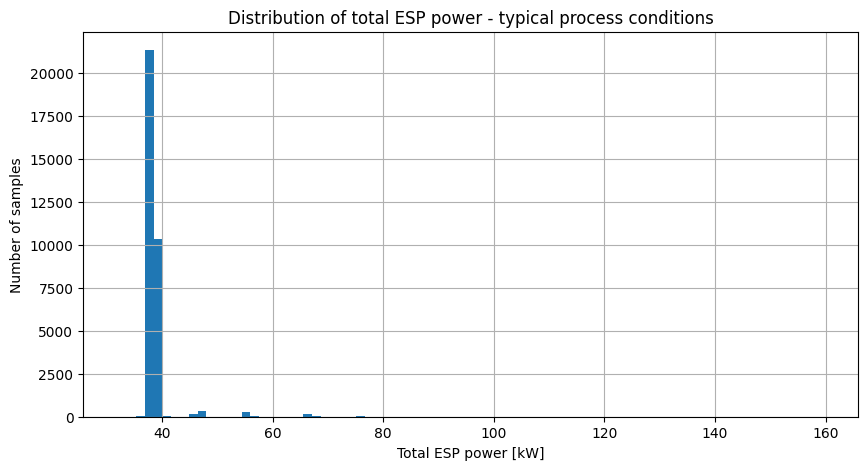

In [21]:
plt.figure(figsize=(10, 5))

plt.hist(df_energy_typical["esp_power_total"], bins=80)

plt.title("Distribution of total ESP power - typical process conditions")
plt.xlabel("Total ESP power [kW]")
plt.ylabel("Number of samples")
plt.grid(True)
plt.show()

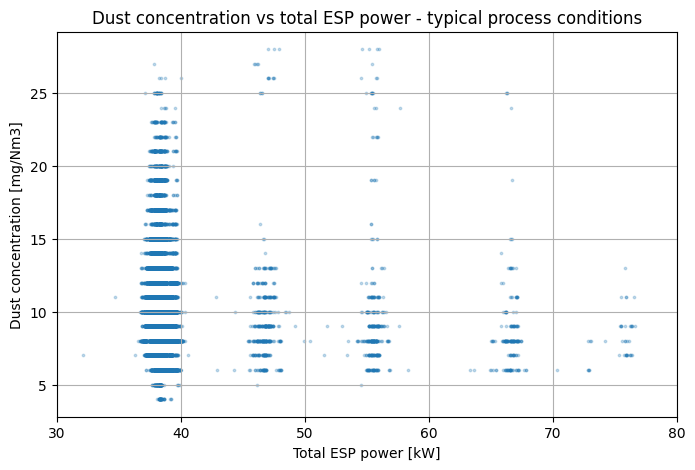

In [22]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_energy_typical["esp_power_total"],
    df_energy_typical[target_col],
    s=3,
    alpha=0.25
)

plt.xlim(30, 80)

plt.title("Dust concentration vs total ESP power - typical process conditions")
plt.xlabel("Total ESP power [kW]")
plt.ylabel("Dust concentration [mg/Nm3]")
plt.grid(True)
plt.show()

In [23]:
df_energy_typical["power_regime"] = pd.cut(
    df_energy_typical["esp_power_total"],
    bins=power_bins,
    labels=power_labels,
    include_lowest=True
)

typical_power_summary = (
    df_energy_typical
    .groupby("power_regime", observed=True)
    .agg(
        n_samples=(target_col, "count"),
        mean_power=("esp_power_total", "mean"),
        median_power=("esp_power_total", "median"),
        mean_dust=(target_col, "mean"),
        median_dust=(target_col, "median"),
        q90_dust=(target_col, lambda x: x.quantile(0.90)),
        q95_dust=(target_col, lambda x: x.quantile(0.95)),
        max_dust=(target_col, "max"),
        mean_boiler_load=("boiler_load_total", "mean"),
        mean_temp=("flue_gas_temp_mean", "mean"),
        mean_o2=("o2_before_esp_mean", "mean"),
    )
    .reset_index()
)

typical_power_summary

,power_regime,n_samples,mean_power,median_power,mean_dust,median_dust,q90_dust,q95_dust,max_dust,mean_boiler_load,mean_temp,mean_o2
0,low_power_30_42,31689,38.297772,38.200001,10.534349,10.0,14.0,16.0,27.0,288.278866,126.413203,6.387818
1,mid_power_42_52,452,46.757301,46.700001,9.672566,9.0,13.0,13.0,28.0,288.453540,126.371681,6.385619
2,high_power_52_65,352,55.652557,55.500001,9.812500,8.0,15.0,24.0,28.0,288.852273,126.207386,6.400852
3,extreme_power_gt_65,226,68.817699,66.799999,8.646018,8.0,11.0,13.0,25.0,289.477876,126.411504,6.391150


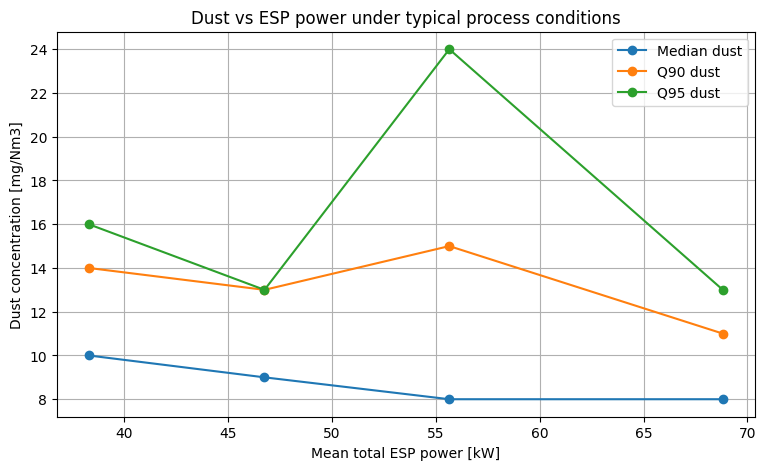

In [24]:
plt.figure(figsize=(9, 5))

plt.plot(
    typical_power_summary["mean_power"],
    typical_power_summary["median_dust"],
    marker="o",
    label="Median dust"
)

plt.plot(
    typical_power_summary["mean_power"],
    typical_power_summary["q90_dust"],
    marker="o",
    label="Q90 dust"
)

plt.plot(
    typical_power_summary["mean_power"],
    typical_power_summary["q95_dust"],
    marker="o",
    label="Q95 dust"
)

plt.title("Dust vs ESP power under typical process conditions")
plt.xlabel("Mean total ESP power [kW]")
plt.ylabel("Dust concentration [mg/Nm3]")
plt.legend()
plt.grid(True)
plt.show()